# EDA: bank_stress_simulated_panel.csv

This notebook explores the raw `bank_stress_simulated_panel.csv` file. This is the
main output of the simulation: 40 banks tested against 500 scenarios each, giving
roughly 20,000 rows. For every bank and scenario pair it records the projected NPL
ratio, the capital ratio, liquidity ratio, and ROA after the shock, and a final label,
`bank_condition`, of Healthy, Stressed, or Critical.

This is the file the whole project is built to produce, so its quality matters more
than any single input file. This notebook only explores and records data-quality
issues. Cleaning happens in `notebooks/data_cleaning.ipynb`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load and inspect

In [2]:
raw = pd.read_csv('../raw/bank_stress_simulated_panel.csv', dtype=str, keep_default_na=False)
print('shape:', raw.shape)
raw.head()

shape: (20025, 24)


,bank_id,scenario_id,size_tier,sector_concentration,total_assets_usd,total_loans_usd,baseline_car_pct,baseline_liquidity_ratio_pct,baseline_roa_pct,gdp_shock_pp,unemp_shock_pp,rate_shock_pp,credit_spread_bps,inflation_shock_pp,fx_devaluation_pct,scenario_severity,weighted_pd_multiplier,projected_npl_ratio_pct,stressed_el_rate_pct,incremental_credit_loss_usd,car_after_pct,roa_after_pct,liquidity_after_pct,bank_condition
0,BANK_001,SCN_0001,medium,concentrated,32427758012.0,22425587704.0,13.79295551718901,131.72444662718556,1.584490631917142,-7.74,6.76,-0.23,332.0,11.06,26.75,adverse,2.722,3.531,2.017,358495484.0,12.12,0.52,104.96,Healthy
1,BANK_002,SCN_0001,medium,diversified,22127519267.0,13812925912.0,14.697693196151016,118.03029030981152,1.1306806751823386,-7.74,6.76,-0.23,332.0,11.06,26.75,adverse,3.0,4.006,2.22,200476229.0,12.67,0.2,101.74,Healthy
2,BANK_003,SCN_0001,large,diversified,49861173736.0,28166601290.0,16.383202004377647,115.21288745053953,0.8906010029512541,-7.74,6.76,-0.23,332.0,11.06,26.75,adverse,3.138,4.744,2.626,575099412.0,13.99,-0.2,104.43,Healthy
3,BANK_004,SCN_0001,medium,diversified,27001020572.0,17118064881.0,15.418764415417758,123.14097134890687,1.2365460651845248,-7.74,6.76,-0.23,332.0,11.06,26.75,adverse,2.84,3.057,1.773,205244116.0,13.44,0.42,99.56,Stressed
4,BANK_005,SCN_0001,small,diversified,2782358312.0,1848267249.0,13.810658251899817,151.5818251282087,1.3639966454293753,-7.74,6.76,-0.23,332.0,11.06,26.75,adverse,2.984,3.9,2.235,29935537.0,11.92,0.26,141.75,Healthy


In [3]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 20025 entries, 0 to 20024
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   bank_id                       20025 non-null  str  
 1   scenario_id                   20025 non-null  str  
 2   size_tier                     20025 non-null  str  
 3   sector_concentration          20025 non-null  str  
 4   total_assets_usd              20025 non-null  str  
 5   total_loans_usd               20025 non-null  str  
 6   baseline_car_pct              20025 non-null  str  
 7   baseline_liquidity_ratio_pct  20025 non-null  str  
 8   baseline_roa_pct              20025 non-null  str  
 9   gdp_shock_pp                  20025 non-null  str  
 10  unemp_shock_pp                20025 non-null  str  
 11  rate_shock_pp                 20025 non-null  str  
 12  credit_spread_bps             20025 non-null  str  
 13  inflation_shock_pp            20025 non-nu

## 2. Duplicate rows

In [4]:
print('Fully duplicated rows:', raw.duplicated().sum())

Fully duplicated rows: 25


**Conclusion.** 25 rows are exact duplicates out of just over 20,000. Each one is
a bank and scenario combination counted twice, which would double-weight that specific
outcome in any summary statistic, such as the share of banks that end up Critical.

## 3. bank_condition: the target label

In [5]:
print('Unique bank_condition values:')
print(sorted(raw['bank_condition'].unique()))
print()
raw['bank_condition'].value_counts(dropna=False)

Unique bank_condition values:
[' Stressed', 'CRITICAL', 'Critcal', 'Critical', 'Critical ', 'HEALTHY', 'Healthy', 'Healthy ', 'Helathy', 'STRESSED', 'Stresed', 'Stressed', 'critical', 'healthy', 'stressed']



bank_condition
Healthy      10147
Stressed      6471
Critical      3107
Helathy         51
HEALTHY         41
healthy         34
Healthy         30
stressed        28
Stresed         27
 Stressed       21
STRESSED        20
Critcal         16
critical        11
Critical        11
CRITICAL        10
Name: count, dtype: int64

**Conclusion.** There should be three outcome categories: Healthy, Stressed,
Critical. Instead there are 13 variants once casing (`HEALTHY`, `healthy`), typos
(`Helathy`, `Stresed`, `Critcal`), and stray whitespace are all counted separately.
This is the single highest priority fix in the whole project, since this column is the
final answer the simulator exists to produce. Left as-is, it would silently create
phantom classes and distort the true proportion of Healthy versus Stressed versus
Critical outcomes.

## 4. scenario_severity: same fragmentation problem

In [6]:
print('Unique scenario_severity values:')
print(sorted(raw['scenario_severity'].unique(), key=str.lower))

Unique scenario_severity values:
[' mild', 'advers', 'adverse', 'Adverse', 'baseline', 'Baseline', 'baseline ', 'mild', 'Mild', 'moderat', 'moderate', 'Moderate', 'sever', 'severe', 'Severe']


**Conclusion.** The same fragmentation problem seen in `macro_scenarios.csv`
carries over into this file, with 15 variants of the 5 real severity levels. This
matters here because severity is how outcomes get sliced later, for example comparing
the average CAR drop under `severe` versus `moderate` scenarios. Fragmented labels
would understate the true size of each severity group.

## 5. car_after_pct: missing values in several disguises

In [7]:
mask_text = raw['car_after_pct'].astype(str).str.contains(r'[^\d.\-]', regex=True, na=False)
print(f'Rows with non-numeric characters: {mask_text.sum()}')
print('Examples:', raw.loc[mask_text, 'car_after_pct'].unique()[:10])

Rows with non-numeric characters: 116
Examples: <StringArray>
['None', 'NA', 'N/A', 'MISSING', 'n/a', ' ', 'missing', 'unknown', 'NULL', 'null']
Length: 10, dtype: str


**Conclusion.** `car_after_pct` is the post-shock capital ratio, the actual
regulatory pass or fail figure the whole project is built around, so how its missing
values are handled matters more than for most other columns. Roughly 0.65 percent of
rows are missing, split between true blanks and disguised text tokens (`MISSING`,
`missing`, `unknown`, a lone space). Small as a share of the data, but worth flagging
rather than silently dropping, since a "cannot assess this bank under this scenario"
row is different from a genuinely missing measurement.

## 6. liquidity_after_pct: a sentinel value hiding in the numbers

In [8]:
liq_numeric = pd.to_numeric(raw['liquidity_after_pct'], errors='coerce')
print(liq_numeric.describe())
print()
print('Rows below 0:', (liq_numeric < 0).sum())
print('Distinct negative values:', liq_numeric[liq_numeric < 0].unique())

count    19896.000000
mean       103.201778
std         23.071143
min         -1.000000
25%         89.040000
50%        104.810000
75%        119.152500
max        158.090000
Name: liquidity_after_pct, dtype: float64

Rows below 0: 21
Distinct negative values: [-1.]


**Conclusion.** A liquidity ratio cannot be negative, so the rows sitting at
exactly -1 are not a real measurement, they are a sentinel value standing in for
missing data. This kind of problem would not be caught by a text or symbol check alone,
since -1 parses as a perfectly normal-looking number. It only shows up by checking
whether the values fall inside a physically plausible range.

## 7. roa_after_pct: a scale error, not random noise

In [9]:
roa_numeric = pd.to_numeric(raw['roa_after_pct'], errors='coerce')
print(roa_numeric.describe())
print()
extreme = roa_numeric[(roa_numeric < -10) | (roa_numeric > 10)]
print('Rows with implausible ROA (outside -10% to 10%):', len(extreme))
print(sorted(extreme.tolist())[:15])

count    20025.000000
mean         0.427877
std          2.591083
min        -70.000000
25%         -0.070000
50%          0.450000
75%          0.890000
max        166.000000
Name: roa_after_pct, dtype: float64

Rows with implausible ROA (outside -10% to 10%): 15
[-70.0, -35.0, -24.0, 21.0, 27.0, 34.0, 48.0, 57.99999999999999, 63.0, 72.0, 119.0, 128.0, 142.0, 153.0, 166.0]


In [10]:
print('Same values divided by 100:')
print(sorted((extreme / 100).tolist())[:15])
print()
print('Overall ROA range once divided by 100:', (roa_numeric / 100).describe()[['min', 'max']])

Same values divided by 100:
[-0.7, -0.35, -0.24, 0.21, 0.27, 0.34, 0.48, 0.58, 0.63, 0.72, 1.19, 1.28, 1.42, 1.53, 1.66]

Overall ROA range once divided by 100: min   -0.70
max    1.66
Name: roa_after_pct, dtype: float64


**Conclusion.** A small number of rows show ROA figures like -70 or 166, far
outside any realistic bank return on assets. Dividing those specific rows by 100 puts
them right back inside the normal range the rest of the column sits in, which points to
a decimal-point-shift bug (a value multiplied by 100 somewhere upstream) rather than
random data corruption. This is worth fixing with a targeted correction on the affected
rows rather than dropping them, since the true value is recoverable.

## 8. size_tier and sector_concentration, carried over from bank_profiles

In [11]:
print('size_tier:')
print(raw['size_tier'].value_counts(dropna=False))
print()
print('sector_concentration:')
print(raw['sector_concentration'].value_counts(dropna=False))

size_tier:
size_tier
medium    9014
small     7007
large     4004
Name: count, dtype: int64

sector_concentration:
sector_concentration
concentrated    10017
diversified     10008
Name: count, dtype: int64


**Conclusion.** These two columns are copied over from `bank_profiles.csv` for
convenience, and carry the same spelling issues found there (`med`, `medim`, `larg`;
`concentratd`). They need the same cleaning map applied here.

## 9. A rough look at outcomes by severity, after a quick fix-up

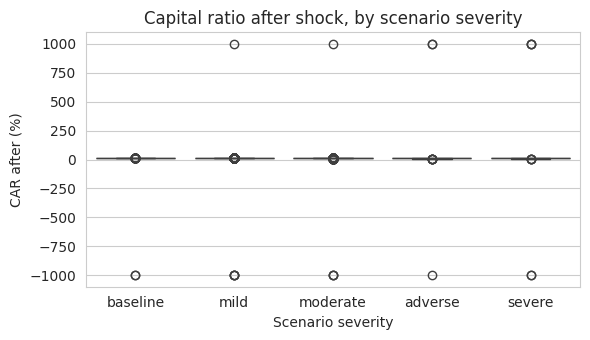

In [12]:
CONDITION_MAP = {
    'healthy': 'Healthy', 'helathy': 'Healthy',
    'stressed': 'Stressed', 'stresed': 'Stressed',
    'critical': 'Critical', 'critcal': 'Critical',
}
SEVERITY_MAP = {
    'baseline': 'baseline',
    'mild': 'mild', 'mld': 'mild',
    'moderate': 'moderate', 'moderat': 'moderate',
    'adverse': 'adverse', 'advers': 'adverse',
    'severe': 'severe', 'sever': 'severe',
}
order = ['baseline', 'mild', 'moderate', 'adverse', 'severe']

preview = pd.DataFrame({
    'bank_condition': raw['bank_condition'].str.strip().str.lower().map(CONDITION_MAP),
    'scenario_severity': raw['scenario_severity'].str.strip().str.lower().map(SEVERITY_MAP),
    'car_after_pct': pd.to_numeric(
        raw['car_after_pct'].replace(['MISSING', 'missing', 'unknown', ' ', ''], np.nan),
        errors='coerce'),
})

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.boxplot(data=preview.dropna(subset=['scenario_severity']), x='scenario_severity',
            y='car_after_pct', order=order, ax=ax)
ax.set_title('Capital ratio after shock, by scenario severity')
ax.set_xlabel('Scenario severity')
ax.set_ylabel('CAR after (%)')
plt.tight_layout()
plt.show()

**Conclusion.** Even with only a quick label fix and no full missing-value or
sentinel cleanup, CAR after the shock already trends downward as severity increases,
which is the expected direction. A more careful cleanup, including the `-1` liquidity
sentinel and the disguised `car_after_pct` tokens, happens in `data_cleaning.ipynb`
before this relationship is used for anything more precise.

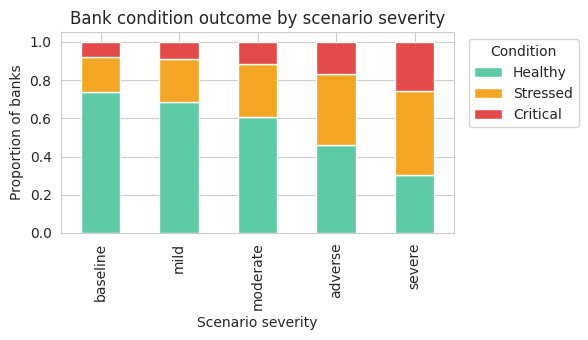

bank_condition      Healthy  Stressed  Critical
scenario_severity                              
baseline           0.735577  0.186538  0.077885
mild               0.686894  0.224630  0.088475
moderate           0.604425  0.281307  0.114268
adverse            0.459772  0.370733  0.169495
severe             0.304857  0.438658  0.256485


In [13]:
ct = pd.crosstab(preview['scenario_severity'], preview['bank_condition'], normalize='index')
ct = ct.reindex(order)
ct = ct[['Healthy', 'Stressed', 'Critical']]

ct.plot(kind='bar', stacked=True, figsize=(6, 3.5), color=['#5DCAA5', '#F2A623', '#E24B4A'])
plt.title('Bank condition outcome by scenario severity')
plt.ylabel('Proportion of banks')
plt.xlabel('Scenario severity')
plt.legend(title='Condition', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()
print(ct)

**Conclusion.** The pattern is exactly what a stress test should show. The share
of Healthy banks shrinks steadily from baseline to severe, while Stressed and Critical
both grow. This is a useful sanity check on its own: it confirms the severity and
condition labels are internally consistent with each other, which is a good sign that
the simulation logic behind them is sound, separately from the text-formatting problems
found above.

## Summary of issues found

- 25 exact duplicate rows.
- `bank_condition` has 13 variants of 3 real categories. Highest priority fix in the
  project, since this is the final output label.
- `scenario_severity` has 15 variants of 5 real categories.
- `car_after_pct` has roughly 130 missing values across true blanks and disguised
  text tokens.
- `liquidity_after_pct` has a `-1` sentinel value standing in for missing data, on top
  of its own blank and text-token missing values.
- `roa_after_pct` has 15 rows with an apparent decimal-point-shift error (values about
  100 times too large).
- `size_tier` and `sector_concentration` repeat the same spelling issues found in
  `bank_profiles.csv`.

All of these are handled in `notebooks/data_cleaning.ipynb`, which writes the cleaned
result to `processed/bank_stress_simulated_panel_clean.csv`.